In [2]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

# Gathering the Data

In [3]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print(file_name)

Saving PJME_hourly.csv to PJME_hourly.csv
PJME_hourly.csv


In [4]:
df = pd.read_csv(file_name)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


# Data Preprocessing & Exploratory Data Analysis
- Convert Datetime column into datetime as Dtype.
- Make graphs to understand the data.
- Remove outliers.

- Conversion to datetime

In [5]:
df = df.set_index('Datetime')

In [6]:
df.index = pd.to_datetime(df.index)

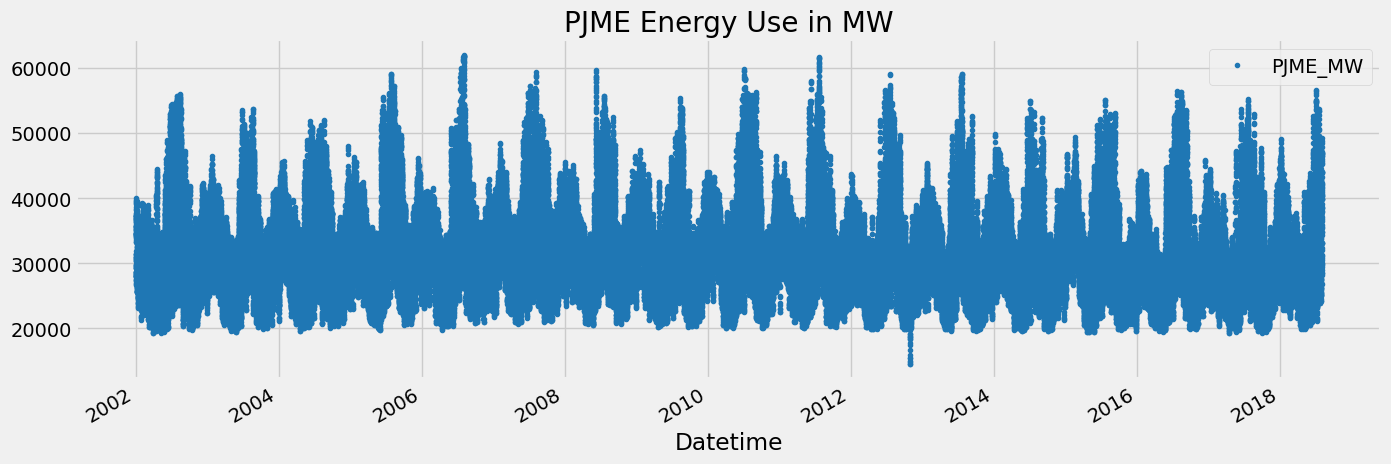

In [7]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='PJME Energy Use in MW')
plt.show()

- Plots to find any outliers.

<Axes: ylabel='Frequency'>

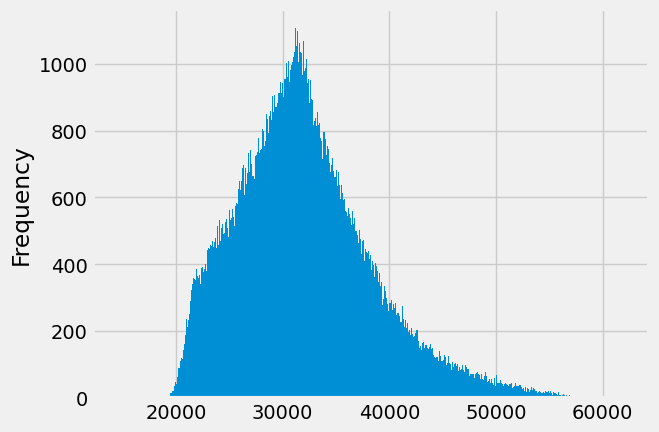

In [8]:
df['PJME_MW'].plot(kind='hist', bins=500)

<Axes: title={'center': 'Outliers'}, xlabel='Datetime'>

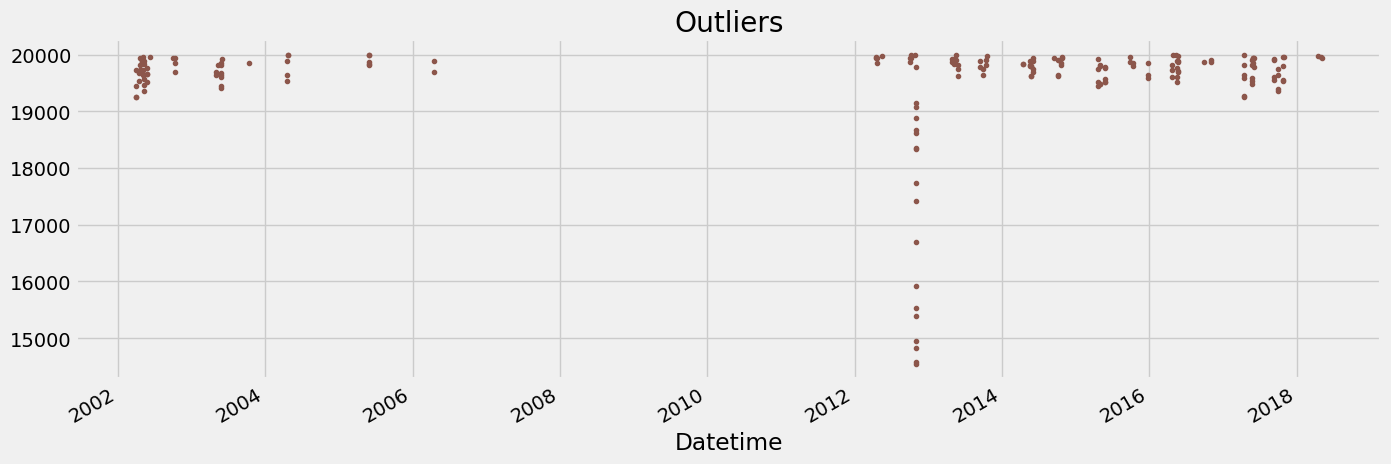

In [9]:
df.query('PJME_MW < 20_000')['PJME_MW'] \
    .plot(style='.',
          figsize=(15, 5),
          color=color_pal[5],
          title='Outliers')

- The above graph gives us idea about the threshold of removing the outliers which is 19000.

<Axes: title={'center': 'Outliers'}, xlabel='Datetime'>

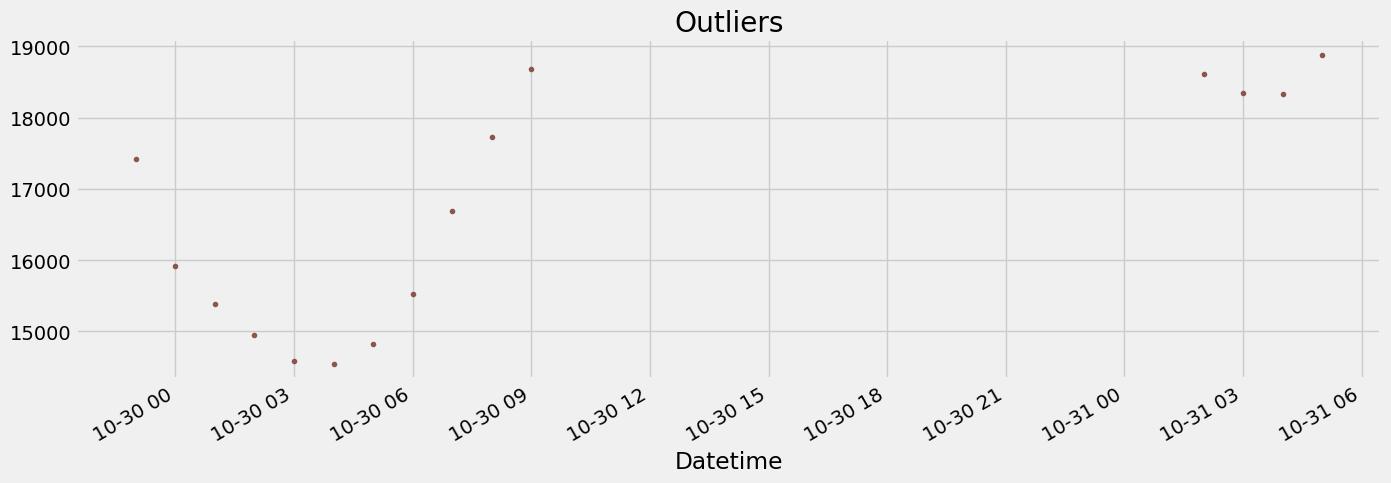

In [10]:
df.query('PJME_MW < 19_000')['PJME_MW'] \
    .plot(style='.',
          figsize=(15, 5),
          color=color_pal[5],
          title='Outliers')

In [11]:
df = df.query('PJME_MW > 19_000').copy()

# Time Series Cross Validation

In [12]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()

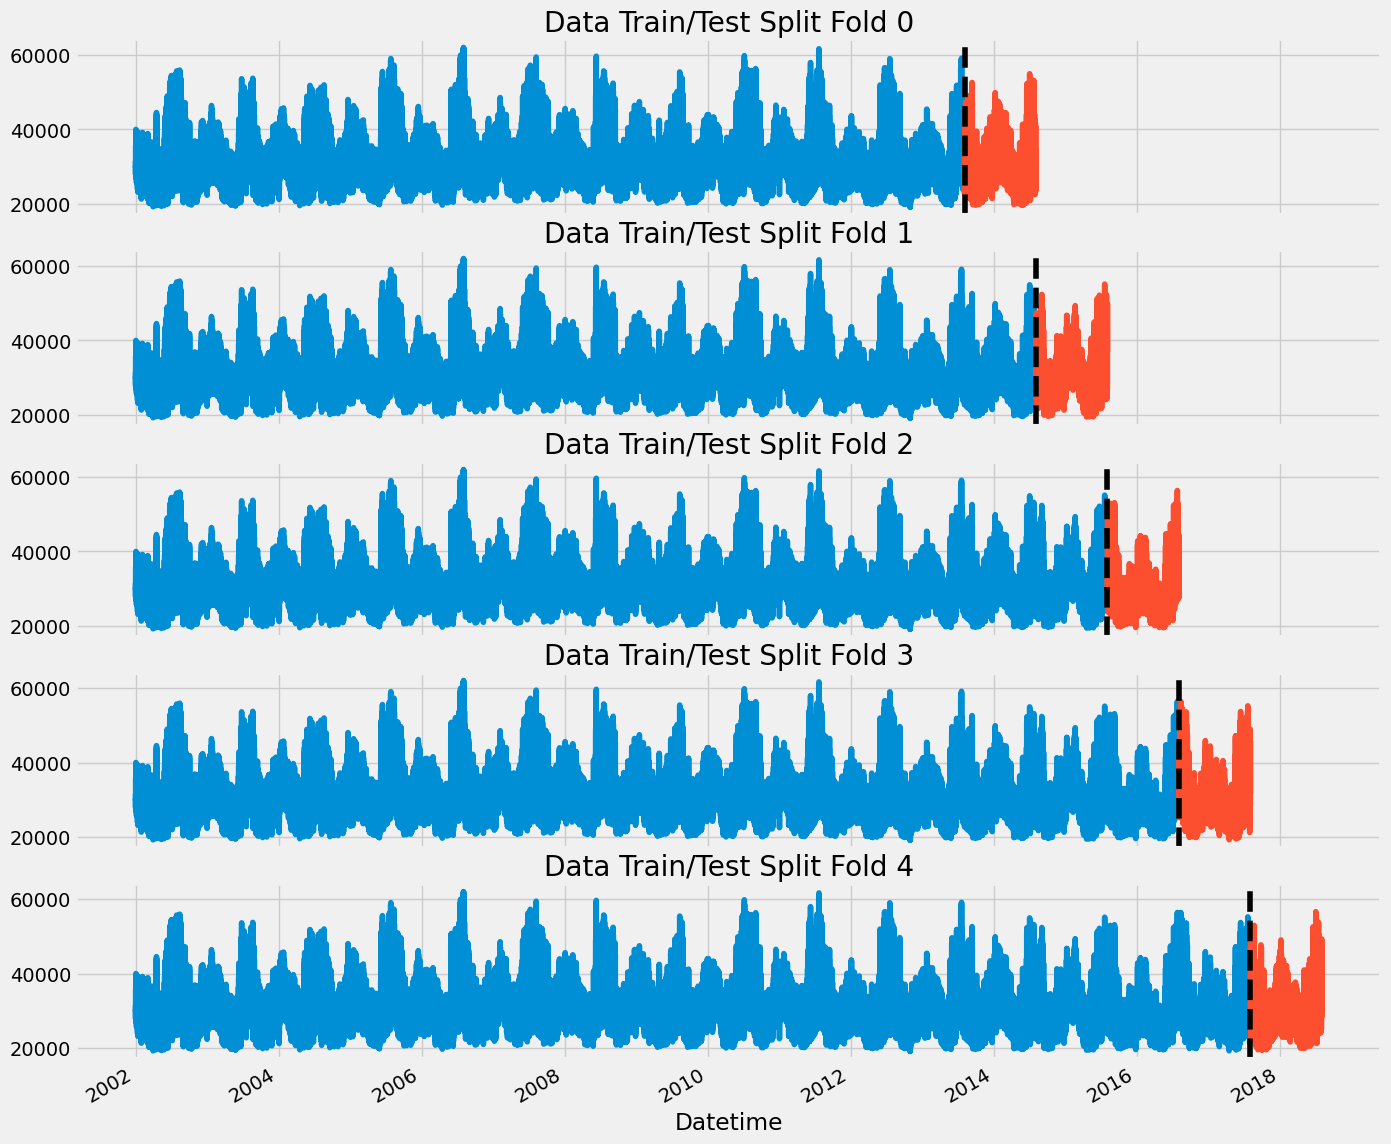

In [13]:
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['PJME_MW'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['PJME_MW'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()

# Feature Engineering

In [14]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

# Training Using Cross Validation

In [15]:
tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()


fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year']
    TARGET = 'PJME_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:linear',
                           max_depth=3,
                           learning_rate=0.01)
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[0]	validation_0-rmse:32734.39307	validation_1-rmse:31955.73013


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [10:54:39] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12615.19340	validation_1-rmse:11908.32049
[200]	validation_0-rmse:5821.04187	validation_1-rmse:5372.57122
[300]	validation_0-rmse:3887.10871	validation_1-rmse:3878.54486
[400]	validation_0-rmse:3420.31301	validation_1-rmse:3733.41452
[500]	validation_0-rmse:3264.88425	validation_1-rmse:3721.42506
[525]	validation_0-rmse:3238.92356	validation_1-rmse:3721.32404
[0]	validation_0-rmse:32674.07421	validation_1-rmse:32138.55154


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [10:54:42] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12605.78505	validation_1-rmse:12124.73403
[200]	validation_0-rmse:5841.43161	validation_1-rmse:5548.96902
[300]	validation_0-rmse:3918.08275	validation_1-rmse:3975.05889
[400]	validation_0-rmse:3455.88375	validation_1-rmse:3698.95085
[500]	validation_0-rmse:3299.00687	validation_1-rmse:3613.92236
[600]	validation_0-rmse:3220.40922	validation_1-rmse:3574.75963
[700]	validation_0-rmse:3169.46813	validation_1-rmse:3537.80601
[800]	validation_0-rmse:3128.01530	validation_1-rmse:3500.87019
[900]	validation_0-rmse:3095.57387	validation_1-rmse:3479.07801
[999]	validation_0-rmse:3067.19425	validation_1-rmse:3464.41684
[0]	validation_0-rmse:32633.16590	validation_1-rmse:31075.40883


...

[100]	validation_0-rmse:12597.18925	validation_1-rmse:11134.48453
[200]	validation_0-rmse:5852.66226	validation_1-rmse:4794.27110
[300]	validation_0-rmse:3947.87147	validation_1-rmse:3611.23846
[400]	validation_0-rmse:3478.46167	validation_1-rmse:3563.43890
[435]	validation_0-rmse:3408.72963	validation_1-rmse:3564.86221
[0]	validation_0-rmse:32530.49136	validation_1-rmse:31471.00841


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [10:54:53] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12565.29715	validation_1-rmse:11683.42118
[200]	validation_0-rmse:5848.14102	validation_1-rmse:5434.47788
[300]	validation_0-rmse:3949.17787	validation_1-rmse:4148.55274
[400]	validation_0-rmse:3476.96973	validation_1-rmse:3981.85260
[500]	validation_0-rmse:3320.35609	validation_1-rmse:3911.91855
[600]	validation_0-rmse:3244.47760	validation_1-rmse:3877.45018
[700]	validation_0-rmse:3192.27186	validation_1-rmse:3856.10134
[800]	validation_0-rmse:3151.46805	validation_1-rmse:3796.69759
[900]	validation_0-rmse:3119.84572	validation_1-rmse:3770.89709
[999]	validation_0-rmse:3093.57539	validation_1-rmse:3759.80577
[0]	validation_0-rmse:32464.20270	validation_1-rmse:31460.18060


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [10:55:02] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12547.49650	validation_1-rmse:11657.22390
[200]	validation_0-rmse:5858.64636	validation_1-rmse:5356.59392
[300]	validation_0-rmse:3975.63193	validation_1-rmse:4089.24624
[400]	validation_0-rmse:3511.33930	validation_1-rmse:3964.66264
[500]	validation_0-rmse:3356.37014	validation_1-rmse:3941.99990
[600]	validation_0-rmse:3279.86164	validation_1-rmse:3928.56495
[700]	validation_0-rmse:3228.91578	validation_1-rmse:3908.98499
[800]	validation_0-rmse:3190.63498	validation_1-rmse:3901.17685
[833]	validation_0-rmse:3179.62033	validation_1-rmse:3901.37547


In [16]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 3680.8712
Fold scores:[np.float64(3719.2451906472893), np.float64(3464.416843927377), np.float64(3562.057134800803), np.float64(3759.5797520985893), np.float64(3899.057327999942)]


# Predicting the Future
- Retraining on all data
- To Predict the future we need an emtpy dataframe for future date ranges.
- Run those dates through our feature creation code.

Why retrain on all data after CV?

Cross-validation is used for model selection and hyperparameter tuning:

It estimates how well the model will generalize.

Once you’re satisfied with hyperparameters n_estimators,etc. , you don’t throw away the data — you use all available history to train a final model.
That way, the model learns from the maximum amount of past information before going live.

This is especially important for time series, where more history usually improves forecasting power.

# Retrain on all data
n_esitmators= 550 observed using CV. For each fold, XGBoost will stop automatically (e.g., at 435, 525, 833 rounds).Take the average across folds, e.g. ~550.

In [17]:
df = create_features(df)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'PJME_MW'

X_all = df[FEATURES]
y_all = df[TARGET]

reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',
                       n_estimators=550,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_all, y_all,
        eval_set=[(X_all, y_all)],
        verbose=100)

[0]	validation_0-rmse:32406.02154


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:10:44] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:12536.44571
[200]	validation_0-rmse:5874.05526
[300]	validation_0-rmse:4007.31510
[400]	validation_0-rmse:3546.24234
[500]	validation_0-rmse:3395.62301
[549]	validation_0-rmse:3354.00330


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=550,
             n_jobs=None, num_parallel_tree=None, ...)

# Empty dataframe creation for Future date ranges.

In [18]:
# Check the maximum date present in our dataset.
df.index.max()

Timestamp('2018-08-03 00:00:00')

In [19]:
# Create future dataframe
future = pd.date_range('2018-08-03','2019-08-01', freq='1h')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)

In [21]:
future_w_features = df_and_future.query('isFuture').copy()

# Predict the Future

In [22]:
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])

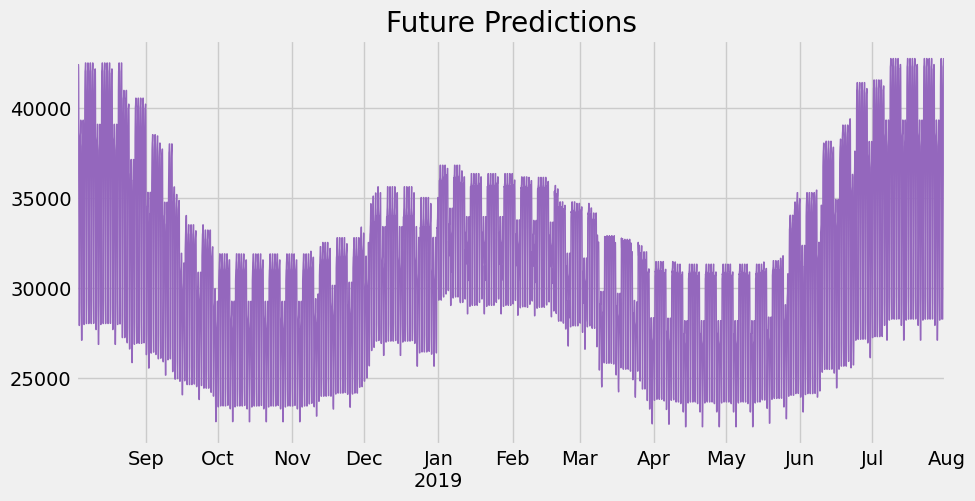

In [23]:
future_w_features['pred'].plot(figsize=(10, 5),
                               color=color_pal[4],
                               ms=1,
                               lw=1,
                               title='Future Predictions')
plt.show()

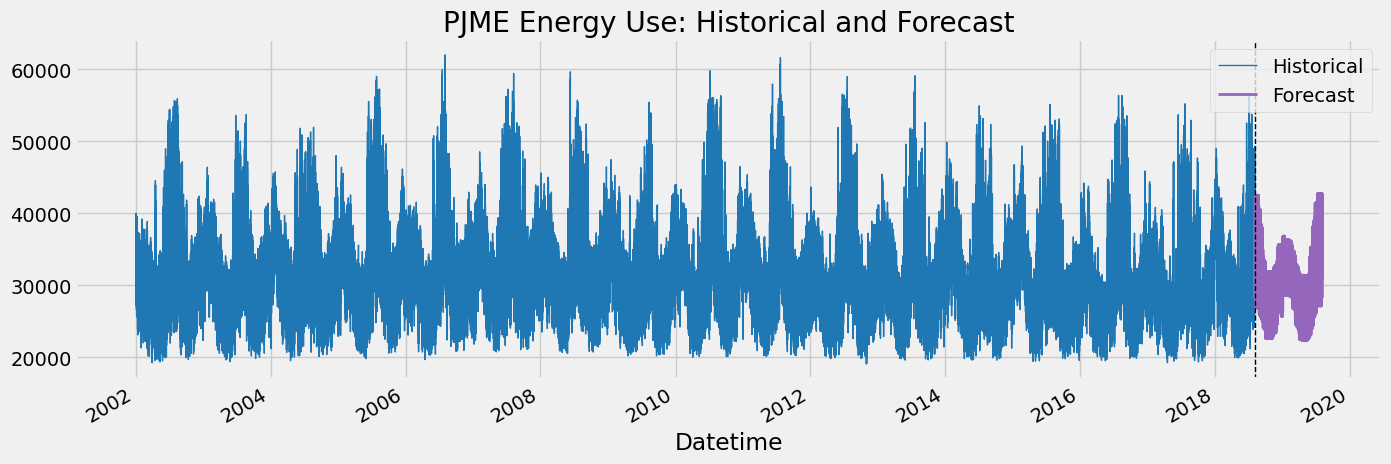

In [24]:
# Plot full history + predictions
fig, ax = plt.subplots(figsize=(15, 5))

# Plot actual historical values
df['PJME_MW'].plot(ax=ax, label='Historical', color=color_pal[0], lw=1)

# Plot predicted future values
future_w_features['pred'].plot(ax=ax, label='Forecast', color=color_pal[4], lw=2)

# Add vertical line at forecast start
ax.axvline(future_w_features.index.min(), color='black', ls='--', lw=1)

ax.set_title("PJME Energy Use: Historical and Forecast")
ax.legend()
plt.show()